First 5 rows:
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye

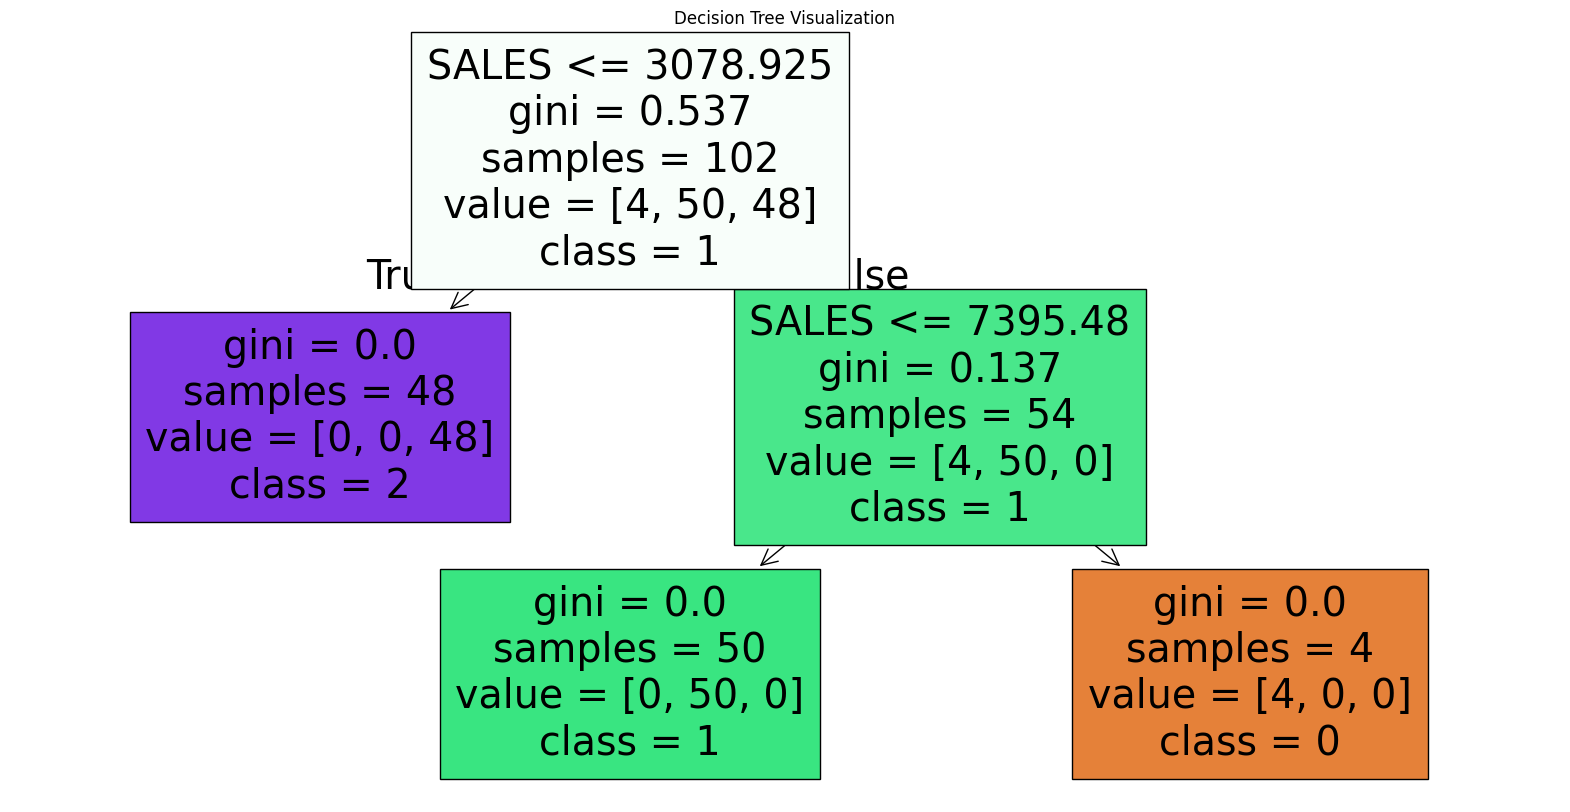


===== Random Forest Results ===R
Accuracy: 0.9777777777777777
Confusion Matrix:
 [[ 0  1  0]
 [ 0 21  0]
 [ 0  0 23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00        23

    accuracy                           0.98        45
   macro avg       0.65      0.67      0.66        45
weighted avg       0.96      0.98      0.97        45



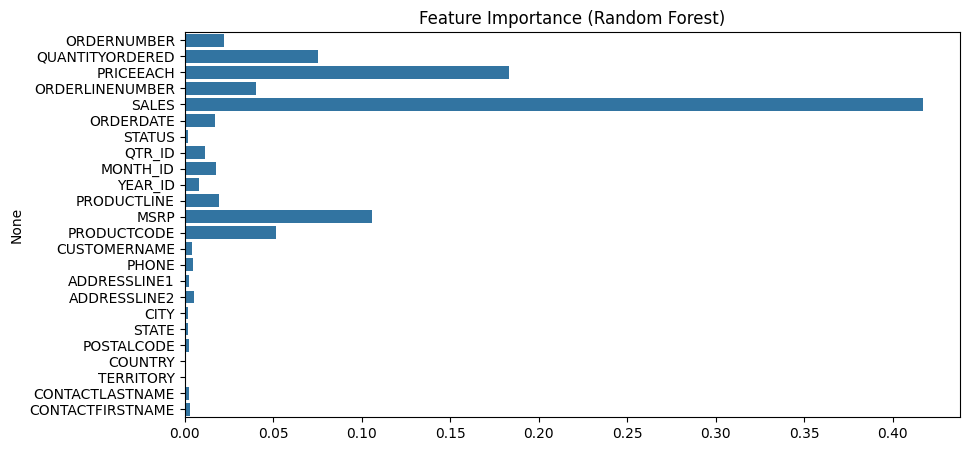

In [5]:
# =========================================
# Experiment: Decision Tree & Random Forest
# =========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load Dataset
# Upload your dataset if using Google Colab
# from google.colab import files
# uploaded = files.upload()

# df = pd.read_csv(list(uploaded.keys())[0])

# If using local system, use:
df = pd.read_csv("/content/sales_data_sample.csv", encoding='latin1')

print("First 5 rows:")
print(df.head())

# Step 3: Handle Missing Values
df = df.dropna()

# Step 4: Encode Categorical Columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Step 5: Define Features and Target
# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================================
# Decision Tree Classifier
# =========================================

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\n===== Decision Tree Results ===R")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("Classification Report:\n", classification_report(y_test, dt_pred))

# Graphical Analysis of Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=[str(i) for i in dt_model.classes_])
plt.title("Decision Tree Visualization")
plt.show()

# =========================================
# Random Forest Classifier
# =========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n===== Random Forest Results ===R")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred, zero_division=0))


# =========================================
# Feature Importance (Random Forest)
# =========================================

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.show()